IMPORTING REQUIRED MODULES

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import regex as re

# MANUAL INSPECTION
DATA DIRTINESS
- age has missing values -5 rows(on programmatic assessment)
- region has missing values -3 rows (on programmatic assessment)

In [ ]:
df=pd.read_csv(r'insurance_data.csv')

In [ ]:
df.info()

WE COULD HAVE CHANGED THE DATATYPE OF AGE COLUMN BUT SINCE SOME VALUES ARE MISSING WE CANNOT FILL IT UP ALTHOUGH WE CAN DROP IT AS ONLY 5 ROWS ARE THERE 

# CATEGORIZING THE COLUMNS
numerical-index,patientid,age,bmi,bloodpressure,claim

categorical-gender,diabetic,smoker,region,children

In [ ]:
df['children'].value_counts()

In [ ]:
df.duplicated().sum()

# UNIVARIATE ANALYSIS ON AGE COLUMN
## conclusions
- all 18 year old (min age) were males
- all 60 year olds(max age) were females
- age column is almost normally distributed
- age has no outlier
- all 53 year olds(the grp with least members) were females
- 5 age rows have no values

In [ ]:
df['age'].describe()

In [ ]:
df.query("age==18")
#all 18 year olds were male

In [ ]:
df.query("age==60")
#all 60 year(max age) olds were females

In [ ]:
df['age'].skew() #almost normally distributed

In [ ]:
df['age'].plot(kind='hist')

In [ ]:
sns.kdeplot(data=df,x='age')

In [ ]:
sns.boxplot(data=df, y='age')
plt.show()

In [ ]:
sns.violinplot(data=df, y='age')
plt.show()

In [ ]:
df['age'].isnull().sum()

In [ ]:
df['age'].value_counts()

In [ ]:
df.query('age==53')
#this is the age with least members and all are females

In [ ]:
df.query('age==38')

In [ ]:
df.query('age==47')

# UNIVARIATE ANALYSIS ON BMI COLUMN
## CONCLUSION
- THE PERSON WITH MAX BMI AND MIN BMI BOTH ARE MALES 
- THE DATA IS NORMALLY DISTRIBUTED
- THERE ARE SOME OUTLIERS
- NO NULL VALUES

In [ ]:
df['bmi'].describe()

In [ ]:
df.query('bmi==16')

In [ ]:
df.query('bmi==53.1')

In [ ]:
df['bmi'].plot(kind='hist')

In [ ]:
sns.kdeplot(data=df,x='bmi')

In [ ]:
df.bmi.skew()

In [ ]:
sns.boxplot(data=df,x='bmi')

In [ ]:
df.query('bmi>45')
#these are the outliers although they don't have any issues with them

In [ ]:
df['bmi'].value_counts()

In [ ]:
df.query('bmi==33.3')

In [ ]:
df['bmi'].duplicated().sum()

# UNIVARIATE ANALYSIS ON BLOODPRESSURE COLUMN
### CONCLUSIONS
- those with highest bloodpressure 140 had very high claims above 35k
- there were outliers above 118 bloodpressure and they also had very high claims
- the bloodpressure column is positively skewed

In [80]:
df['bloodpressure'].describe()

count    1340.000000
mean       94.157463
std        11.434712
min        80.000000
25%        86.000000
50%        92.000000
75%        99.000000
max       140.000000
Name: bloodpressure, dtype: float64

In [81]:
df.query('bloodpressure==80')

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
30,30,31,29.0,male,20.4,80,Yes,0,No,northwest,1625.43
31,31,32,49.0,male,21.8,80,No,0,No,northwest,1627.28
47,47,48,31.0,male,39.5,80,Yes,0,No,southwest,1682.60
55,55,56,21.0,male,23.3,80,Yes,1,No,northwest,1711.03
60,60,61,49.0,male,35.2,80,Yes,1,No,southeast,1727.54
69,69,70,32.0,male,29.7,80,Yes,0,No,northwest,1769.53
71,71,72,48.0,male,32.6,80,Yes,0,No,southeast,1824.29
89,89,90,23.0,male,33.0,80,Yes,1,No,northwest,1980.07
105,105,106,43.0,female,35.2,80,No,0,No,northwest,2134.90


In [84]:
df.query('bloodpressure==140')
#the people with 140 blood pressure had very high claims above 35k

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1210,1210,1211,25.0,male,30.8,140,Yes,0,Yes,southwest,35491.64
1225,1225,1226,50.0,female,34.8,140,Yes,2,No,southwest,36910.61
1226,1226,1227,46.0,male,35.5,140,Yes,0,Yes,southeast,36950.26
1242,1242,1243,27.0,female,36.7,140,No,2,Yes,northeast,38511.63
1290,1290,1291,47.0,male,41.9,140,Yes,3,Yes,northeast,43753.34


<Axes: ylabel='Frequency'>

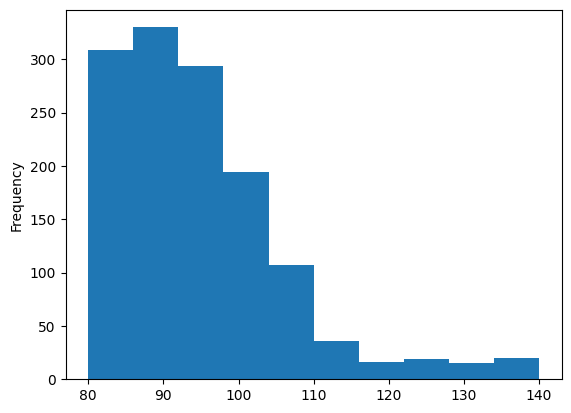

In [86]:
df['bloodpressure'].plot(kind='hist')

<Axes: xlabel='bloodpressure', ylabel='Density'>

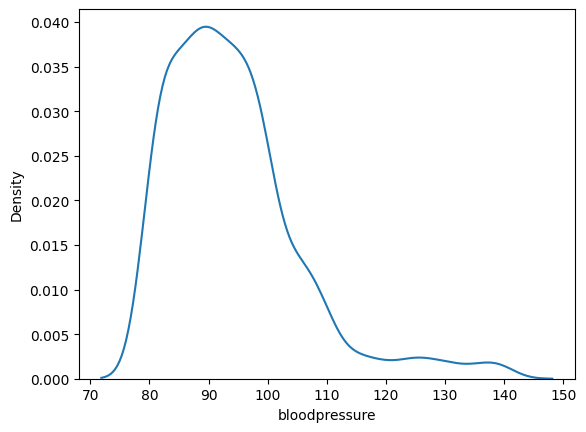

In [88]:
sns.kdeplot(data=df,x='bloodpressure')

<Axes: ylabel='bloodpressure'>

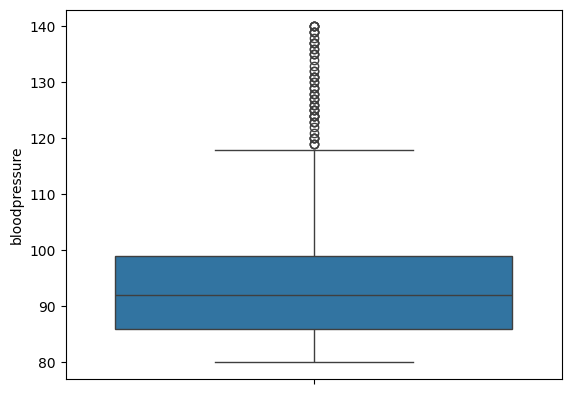

In [89]:
sns.boxplot(data=df,y='bloodpressure')

In [95]:
df.query('bloodpressure>118')
#there were outliers above 118 and all of them had very high claim

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1147,1147,1148,29.0,female,32.7,128,Yes,2,No,northwest,26018.95
1150,1150,1151,55.0,female,27.1,135,No,1,No,southwest,26140.36
1152,1152,1153,38.0,female,35.9,128,No,1,No,northeast,26392.26
1153,1153,1154,43.0,male,36.8,126,No,2,No,northwest,26467.10
1154,1154,1155,31.0,male,23.8,126,Yes,0,Yes,southeast,26926.51
...,...,...,...,...,...,...,...,...,...,...,...
1325,1325,1326,52.0,female,36.4,133,Yes,1,Yes,northeast,48517.56
1332,1332,1333,26.0,male,37.0,120,No,2,Yes,southeast,49577.66
1333,1333,1334,44.0,male,36.4,127,No,1,Yes,southwest,51194.56
1334,1334,1335,43.0,male,32.8,125,No,0,Yes,southwest,52590.83


In [96]:
df['bloodpressure'].skew()

np.float64(1.4835342102293079)

In [99]:
df['bloodpressure'].value_counts()

bloodpressure
91     62
80     59
88     58
81     58
89     58
       ..
138     1
116     1
134     1
121     1
133     1
Name: count, Length: 61, dtype: int64

In [102]:
df['bloodpressure'].isnull().sum()

np.int64(0)